In [46]:
import matplotlib.pyplot as plt
import math
import csv
import pandas as pd
import numpy as np

global Ts 
Ts = 0.00005   #1/200000
global Vdc 
Vdc = 24
global pi 
pi = 180

global Iterm
Iterm = 0

global Ki
global Kp
Ki = 0.05
Kp = 0.002

In [47]:
def rtd(degree):
    return math.degrees(degree)
def dtr(radian):
    return math.radians(radian)


In [62]:
def clarketf(a, b, c):
    alpha = (2/3)*(a - 0.5*b - 0.5*c)
    beta =(2/3)*(math.sqrt(3)*(1/2)*b - math.sqrt(3)*(1/2)*c)
    output = [alpha, beta]
    return output

theta_elec = 0

a = math.sin(dtr(theta_elec))*Vdc
b = math.sin(dtr(theta_elec+120))*Vdc
c = math.sin(dtr(theta_elec+240))*Vdc

print(a)
print(b)
print(c)

clarke = clarketf(a,b,c)
print(clarke[0])
print(clarke[1])


0.0
20.78460969082653
-20.78460969082652
-3.552713678800501e-15
24.0


In [63]:
def thetacalc(alpha, beta):
    
    alpha_abs = abs(alpha)
    
    beta_abs = abs(beta)
    
    alphasign = 1
    betasign = 1
    
    if alpha < 0: 
        alphasign = -1
    else :
        alphasign = 1
        
    if beta < 0:
        betasign = -1
    else: 
        betasign = 1
        
    # 0<=theta<45    
    if alphasign == 1 and betasign == 1:
        if alpha_abs > beta_abs: #1
            theta = rtd(math.atan(beta/alpha))
            return theta
        elif alpha_abs < beta_abs: #2
            theta = 90 - rtd(math.atan(alpha/beta))
            return theta
        elif beta_abs == 0:
            thata = 0
            return theta
        elif beta_abs == alpha_abs:
            theta = 45
            return theta
      
    # 90<=theta<180
    elif alphasign == -1 and betasign == 1:
        if alpha_abs > beta_abs: #4
            theta = 180 - rtd(math.atan(beta/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #3
            theta = 90 + rtd(math.atan(alpha_abs/beta))
            return theta
        elif alpha_abs == 0:
            thata = 90
            return theta
        elif alpha_abs == beta_abs:
            theta = 135
            return theta

    # 180<=theta<270
    elif alphasign == -1 and betasign == -1:
        if alpha_abs > beta_abs: #5
            theta = 180 + rtd(math.atan(beta_abs/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #6
            theta = 270 - rtd(math.atan(alpha_abs/beta_abs))
            return theta
        elif beta_abs == 0:
            thata = 180
            return theta
        elif alpha_abs == beta_abs:
            theta = 225
            return theta

    # 270<=theta<360
    elif alphasign == 1 and betasign == -1:
        if alpha_abs > beta_abs: #8
            theta = 360 - rtd(math.atan(beta_abs/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #7
            theta = 270 + rtd(math.atan(alpha_abs/beta_abs))
            return theta
        elif alpha_abs == 0:
            thata = 270
            return theta
        elif alpha_abs == beta_abs:
            theta = 315
            return theta
        
print(clarke[0])
print(clarke[1])

alpha = clarke[0]
beta = clarke[1]

theta = thetacalc(alpha, beta)
print(theta)

    

-3.552713678800501e-15
24.0
90.00000000000001


In [70]:
def parktf(alpha, beta, theta):
    d = math.cos(dtr(theta))*alpha + math.sin(dtr(theta))*beta*-1
    q = math.sin(dtr(theta))*alpha + math.cos(dtr(theta))*beta
    
    output = [d,q]
    return output

park = parktf(alpha, beta, theta)
print(park)

[-23.98537984845829, -0.8375879208600244]


In [65]:
def PIctrl(ref, feedback):
    error = ref - feedback
    
    return 0

In [71]:
def svm_tcalc(theta, vref):

    
    vref = abs(vref)
    N = 0
    
    if theta>=0 and theta<60:
        n = 1
    elif theta>=60 and theta<120:
        n = 2
    elif theta>=120 and theta<180:
        n = 3
    elif theta>=180 and theta<240:
        n = 4
    elif theta>=240 and theta<300:
        n = 5
    elif theta>=300 and theta<360:
        n = 6
    
    if n == 1:
        N = 6
    else:
        N = n-1
        
    
    T1 = math.sqrt(3)*Ts*vref/Vdc*math.sin(dtr(n*60-theta))
    T2 = math.sqrt(3)*Ts*vref/Vdc*math.sin(dtr(theta-N*60))
    T0 = Ts - (T1+T2)
    
    flag = 0
    
    if T0 < 0:
        flag = 1
    else:
        flag = 0
    
    result = [T1, T2, T0, flag]
    
    return result

vref = park[1]
print(theta)
svm_time = svm_tcalc(theta, vref)

print(svm_time)
    
    

91.0
[1.4652813591718192e-06, 1.5566433893081216e-06, 4.697807525152006e-05, 0]


In [72]:
degree = 0

f = open('data.csv', 'w', encoding='utf-8', newline='')
wr = csv.writer(f)
wr.writerow(['T1', 'T2', 'T0', 'flag' ,'vref', 'theta', 'alpha', 'beta'])

while degree < 360:
    theta_elec = degree

    degree = degree + 1
    
    a = math.sin(dtr(theta_elec))*Vdc
    b = math.sin(dtr(theta_elec+120))*Vdc
    c = math.sin(dtr(theta_elec+240))*Vdc
    
    clarke = clarketf(a,b,c)
    
    alpha = clarke[0]
    beta = clarke[1]
    
    theta = thetacalc(alpha, beta)
    
    park = parktf(alpha, beta, theta)
    
    vref = park[1]
    
    svm_time = svm_tcalc(theta, vref)
    
    wr.writerow([svm_time[0],svm_time[1],svm_time[2],svm_time[3], park[1], theta, alpha, beta])
    
f.close()



Index(['T1', 'T2', 'T0', 'flag', 'vref', 'theta', 'alpha', 'beta'], dtype='object')
             T1            T2        T0  flag          vref  theta  \
0  1.337325e-20  1.337325e-20  0.000050     0 -7.412208e-15   90.0   
1  1.556643e-06  1.465281e-06  0.000047     0  8.375879e-01   89.0   
2  3.201289e-06  2.836119e-06  0.000044     0  1.674155e+00   88.0   
3  4.930307e-06  4.109717e-06  0.000041     0  2.508683e+00   87.0   
4  6.739809e-06  5.283575e-06  0.000038     0  3.340154e+00   86.0   

          alpha       beta  
0 -3.552714e-15  24.000000  
1  4.188578e-01  23.996345  
2  8.375879e-01  23.985380  
3  1.256063e+00  23.967109  
4  1.674155e+00  23.941537  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T1      360 non-null    float64
 1   T2      360 non-null    float64
 2   T0      360 non-null    float64
 3   flag    360 non-null    in

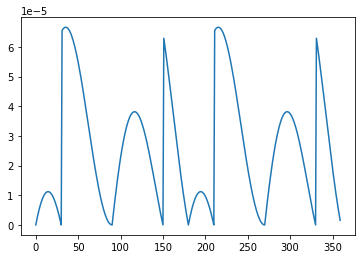

In [73]:
df1 = pd.read_csv("data.csv", encoding = 'utf-8')
print(df1.columns)
print(df1.head())
print()
print(df1.info())

print("--------------------")
T1list = df1.loc[:,"T1"]
T2list = df1.loc[:,"T2"]

degrees = np.arange(0,360,1)


plt.plot(degrees, T2list)

$$\sin\theta = \sum_{i=0}^\infty \frac{1}{i!}$$

In [12]:
f = open('data.csv', 'w', encoding='utf-8', newline='')
wr = csv.writer(f)
wr.writerow(svm_time)
f.close()


